# Periodicity Gate Injection Benchmark

This notebook benchmarks the pre-periodicity gate and downstream dip recovery on injected light curves built from the bundled ASAS-SN `.dat3` controls. It compares three configurations:

- `standard_only`: standard MALCA event scoring with the configured default baseline.
- `phase_folded_only`: run the gate, then score every trial with the phase-template baseline using the gate-selected period.
- `bifurcated_gate`: route periodic gate labels to phase-template scoring and non-periodic labels to standard scoring.

Full mode defaults to a balanced 6k-trial benchmark with a coarse `500`-period CE gate scan and `10` worker processes. The expensive `5000`-period scan is reserved for the period-search subset sweep unless you explicitly set `MALCA_PGIB_GATE_N_PERIODS=5000`. For execution checks, set `MALCA_PGIB_SMOKE=1` before running the notebook.

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/malca-matplotlib")

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not find repo root")

REPO_ROOT = find_repo_root(Path.cwd().resolve())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Repo root: {REPO_ROOT}")

Repo root: /home/calder/code/malca


In [2]:
import pandas as pd
from IPython.display import Image, display

from malca.evaluation.periodicity_gate_injection_benchmark import (
    BenchmarkConfig,
    BENCHMARK_CLASS_ORDER,
    run_benchmark,
)

def env_bool(name: str, default: bool = False) -> bool:
    value = os.environ.get(name)
    if value is None:
        return default
    return str(value).strip().lower() in {"1", "true", "yes", "y", "on"}

def env_int(name: str, default: int) -> int:
    value = os.environ.get(name)
    return default if value is None or str(value).strip() == "" else int(value)

def env_float(name: str, default: float) -> float:
    value = os.environ.get(name)
    return default if value is None or str(value).strip() == "" else float(value)

SMOKE_MODE = env_bool("MALCA_PGIB_SMOKE", False)
RUN_TAG = os.environ.get("MALCA_PGIB_RUN_TAG")

config = BenchmarkConfig(
    bundle_lc_dir=REPO_ROOT / "output/runs/runs_march18_bundle_all/bundle_assets/lightcurves",
    output_base_dir=REPO_ROOT / "output/diagnostics/periodicity_gate_injection_benchmark",
    run_tag=RUN_TAG,
    smoke_mode=SMOKE_MODE,
    total_trials=env_int("MALCA_PGIB_TOTAL_TRIALS", 6000),
    smoke_total_trials=env_int("MALCA_PGIB_SMOKE_TRIALS", 512),
    control_sample_size=env_int("MALCA_PGIB_CONTROL_SAMPLE_SIZE", 205),
    smoke_control_sample_size=env_int("MALCA_PGIB_SMOKE_CONTROL_SAMPLE_SIZE", 96),
    gate_n_periods=env_int("MALCA_PGIB_GATE_N_PERIODS", 500),
    smoke_gate_n_periods=env_int("MALCA_PGIB_SMOKE_GATE_N_PERIODS", 800),
    period_search_subset_size=env_int("MALCA_PGIB_PERIOD_SEARCH_SUBSET", 100),
    smoke_period_search_subset_size=env_int("MALCA_PGIB_SMOKE_PERIOD_SEARCH_SUBSET", 64),
    workers=env_int("MALCA_PGIB_WORKERS", 10),
    trial_task_size=env_int("MALCA_PGIB_TRIAL_TASK_SIZE", 1),
    baseline_func=os.environ.get("MALCA_PGIB_BASELINE_FUNC", "gp_masked"),
    min_mag_offset=env_float("MALCA_PGIB_MIN_MAG_OFFSET", 0.1),
    cache_generated_lightcurves=env_bool("MALCA_PGIB_CACHE_LIGHTCURVES", True),
    post_filter_apply_periodic_catalog_validation=env_bool("MALCA_PGIB_POST_FILTER_CATALOG", False),
    post_filter_apply_gaia_ruwe_validation=env_bool("MALCA_PGIB_POST_FILTER_GAIA_RUWE", False),
    post_filter_apply_gaia_pm_validation=env_bool("MALCA_PGIB_POST_FILTER_GAIA_PM", False),
    post_filter_apply_periodicity_validation=env_bool("MALCA_PGIB_POST_FILTER_PERIODICITY", False),
)

print("Benchmark configuration")
print(f"  smoke_mode: {config.smoke_mode}")
print(f"  trials: {config.effective_total_trials:,}")
print(f"  controls: {config.effective_control_sample_size:,}")
print(f"  baseline_func: {config.baseline_func}")
print(f"  workers: {config.workers}")
print(f"  gate_n_periods: {config.effective_gate_n_periods:,}")
print(f"  bundle_lc_dir: {config.bundle_lc_dir}")
print(f"  output_base_dir: {config.output_base_dir}")

/home/calder/miniforge3/envs/malca/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Benchmark configuration
  smoke_mode: False
  trials: 60,000
  controls: 2,048
  baseline_func: gp_masked
  workers: 10
  gate_n_periods: 500
  bundle_lc_dir: /home/calder/code/malca/output/runs/runs_march18_bundle_all/bundle_assets/lightcurves
  output_base_dir: /home/calder/code/malca/output/diagnostics/periodicity_gate_injection_benchmark


## Run Benchmark

This cell writes all required artifacts under `output/diagnostics/periodicity_gate_injection_benchmark/<run_tag>/`:

- `trial_design.parquet`
- `trial_results.parquet`
- `gate_threshold_sweep.parquet`
- `period_search_subset_sweep.parquet`
- `post_filter_results.parquet`
- `post_filter_rejection_summary.parquet`
- `summary_metrics.parquet`

In [3]:
run = run_benchmark(config)

print(f"Run directory: {run.run_dir}")
for name in [
    "trial_design.parquet",
    "trial_results.parquet",
    "gate_threshold_sweep.parquet",
    "period_search_subset_sweep.parquet",
    "post_filter_results.parquet",
    "post_filter_rejection_summary.parquet",
    "summary_metrics.parquet",
]:
    path = run.run_dir / name
    print(f"  {name}: {path.exists()}  {path}")

Benchmark trials (10 workers):  19%|█▊        | 11198/60000 [47:35<3:32:34,  3.83it/s] /home/calder/miniforge3/envs/malca/lib/python3.10/site-packages/scipy/optimize/_lsq/common.py:115: RuntimeWarning: divide by zero encountered in divide
  phi_prime = -np.sum(suf ** 2 / denom**3) / p_norm
Benchmark trials (10 workers):  30%|██▉       | 17787/60000 [1:11:01<2:12:53,  5.29it/s] /home/calder/miniforge3/envs/malca/lib/python3.10/site-packages/scipy/optimize/_lsq/common.py:115: RuntimeWarning: divide by zero encountered in divide
  phi_prime = -np.sum(suf ** 2 / denom**3) / p_norm
/home/calder/miniforge3/envs/malca/lib/python3.10/site-packages/scipy/optimize/_lsq/common.py:115: RuntimeWarning: divide by zero encountered in divide
  phi_prime = -np.sum(suf ** 2 / denom**3) / p_norm
Benchmark trials (10 workers):  61%|██████    | 36431/60000 [2:18:46<2:49:02,  2.32it/s] /home/calder/miniforge3/envs/malca/lib/python3.10/site-packages/scipy/optimize/_lsq/common.py:115: RuntimeWarning: divide b

Run directory: /home/calder/code/malca/output/diagnostics/periodicity_gate_injection_benchmark/20260513_162637
  trial_design.parquet: True  /home/calder/code/malca/output/diagnostics/periodicity_gate_injection_benchmark/20260513_162637/trial_design.parquet
  trial_results.parquet: True  /home/calder/code/malca/output/diagnostics/periodicity_gate_injection_benchmark/20260513_162637/trial_results.parquet
  gate_threshold_sweep.parquet: True  /home/calder/code/malca/output/diagnostics/periodicity_gate_injection_benchmark/20260513_162637/gate_threshold_sweep.parquet
  period_search_subset_sweep.parquet: True  /home/calder/code/malca/output/diagnostics/periodicity_gate_injection_benchmark/20260513_162637/period_search_subset_sweep.parquet
  summary_metrics.parquet: True  /home/calder/code/malca/output/diagnostics/periodicity_gate_injection_benchmark/20260513_162637/summary_metrics.parquet


## Sanity Checks

In [4]:
class_counts = run.trial_design["class_name"].value_counts().reindex(BENCHMARK_CLASS_ORDER).fillna(0).astype(int)
display(class_counts.rename("n_trials").to_frame())

required_result_columns = ["standard_detected", "phase_folded_detected", "bifurcated_detected"]
missing = [col for col in required_result_columns if col not in run.trial_results.columns]
if missing:
    raise AssertionError(f"Missing required result columns: {missing}")
if (class_counts <= 0).any():
    raise AssertionError("At least one injected class has zero trials")

default_gate_counts = pd.crosstab(run.trial_results["target_gate_label"], run.trial_results["pre_periodicity_label"])
display(default_gate_counts)

distinct_branch_loads = run.gate_threshold_sweep.loc[run.gate_threshold_sweep["scope"] == "all", "periodic_branch_load"].nunique()
print(f"Distinct threshold-sweep branch loads: {distinct_branch_loads}")
if distinct_branch_loads < 2:
    print("Warning: threshold sweep did not change branch load on this sample; increase smoke trials or gate resolution.")

,n_trials
class_name,
no_injection_control,7500
single_non_recurrent_dip,7500
non_periodic_recurrent_dips,7500
semi_periodic_dips,7500
periodic_fixed_depth_dips,7500
periodic_varying_depth_dips,7500
broad_long_dips,7500
smooth_periodic_contaminant,7500


pre_periodicity_label,non_periodic,periodic
target_gate_label,,
ambiguous,6019,1481
non_periodic,26753,3247
periodic,8338,14162


Distinct threshold-sweep branch loads: 74


## Summary Tables

In [5]:
summary_cols = [
    "scope",
    "class_name",
    "pipeline",
    "n",
    "raw_detected_n",
    "target_recovery",
    "false_positive_rate",
    "detection_rate",
    "post_filter_passed_n",
    "post_filter_target_recovery",
    "final_false_positive_rate",
    "post_filter_detection_rate",
    "gate_periodic_fraction",
    "period_usable_rate",
    "gate_periodic_recall",
    "gate_false_periodic_route_rate",
]
display(run.summary_metrics[summary_cols].sort_values(["scope", "pipeline", "class_name"]))
display(run.post_filter_rejection_summary.sort_values(["scope", "pipeline", "class_name", "filter"]))

sweep_all = run.gate_threshold_sweep[run.gate_threshold_sweep["scope"] == "all"].copy()
display(
    sweep_all.sort_values(["target_recovery", "gate_false_periodic_route_rate"], ascending=[False, True])
    .head(15)
)

display(run.period_search_subset_sweep.sort_values(["period_usable_rate", "gate_periodic_recall"], ascending=[False, False]))

,scope,class_name,pipeline,n,target_recovery,false_positive_rate,detection_rate,gate_periodic_fraction,period_usable_rate,gate_periodic_recall,gate_false_periodic_route_rate
18,all,ALL,bifurcated_gate,60000,0.906978,0.689600,0.852633,0.314833,0.729333,0.629422,0.108233
9,all,ALL,phase_folded_only,60000,0.798200,0.689200,0.770950,0.314833,0.729333,0.629422,0.108233
0,all,ALL,standard_only,60000,0.949178,0.546733,0.848567,0.314833,0.729333,0.629422,0.108233
23,class,broad_long_dips,bifurcated_gate,7500,0.979733,NaN,0.979733,0.072000,NaN,NaN,0.072000
20,class,no_injection_control,bifurcated_gate,7500,NaN,0.878133,0.878133,0.123733,NaN,NaN,0.123733
25,class,non_periodic_recurrent_dips,bifurcated_gate,7500,0.959467,NaN,0.959467,0.108667,NaN,NaN,0.108667
19,class,periodic_fixed_depth_dips,bifurcated_gate,7500,0.777600,NaN,0.777600,0.670000,0.832933,0.670000,NaN
26,class,periodic_varying_depth_dips,bifurcated_gate,7500,0.903200,NaN,0.903200,0.685067,0.780267,0.685067,NaN
21,class,semi_periodic_dips,bifurcated_gate,7500,0.892267,NaN,0.892267,0.197467,0.440400,NaN,NaN
22,class,single_non_recurrent_dip,bifurcated_gate,7500,0.929600,NaN,0.929600,0.128533,NaN,NaN,0.128533


,scope,class_name,ce_snr_threshold,scatter_ratio_max,phase_peak_snr_min,periodic_branch_load,target_recovery,false_positive_rate,detection_rate,gate_hard_n,gate_periodic_recall,gate_non_periodic_specificity,gate_false_periodic_route_rate,gate_accuracy
558,all,ALL,14.0,0.65,3.0,0.087433,0.937400,0.576467,0.847167,52500,0.198267,0.979333,0.020667,0.644590
585,all,ALL,14.0,0.75,3.0,0.089650,0.936822,0.576467,0.846733,52500,0.202533,0.979300,0.020700,0.646400
612,all,ALL,14.0,0.80,3.0,0.090233,0.936711,0.576267,0.846600,52500,0.203778,0.979300,0.020700,0.646933
549,all,ALL,14.0,0.65,2.5,0.091017,0.936644,0.577533,0.846867,52500,0.206222,0.978867,0.021133,0.647733
639,all,ALL,14.0,0.90,3.0,0.091200,0.936578,0.576000,0.846433,52500,0.205778,0.979300,0.020700,0.647790
666,all,ALL,14.0,1.00,3.0,0.091667,0.936311,0.575933,0.846217,52500,0.206711,0.979300,0.020700,0.648190
540,all,ALL,14.0,0.65,2.0,0.094117,0.936200,0.579333,0.846983,52500,0.213244,0.978433,0.021567,0.650495
576,all,ALL,14.0,0.75,2.5,0.093267,0.936067,0.577467,0.846417,52500,0.210622,0.978833,0.021167,0.649600
603,all,ALL,14.0,0.80,2.5,0.093883,0.935933,0.577267,0.846267,52500,0.211911,0.978833,0.021167,0.650152
630,all,ALL,14.0,0.90,2.5,0.094817,0.935800,0.577000,0.846100,52500,0.213822,0.978833,0.021167,0.650971


,n_periods,min_period,max_period,n,periodic_branch_load,period_usable_rate,gate_hard_n,gate_periodic_recall,gate_non_periodic_specificity,gate_false_periodic_route_rate,gate_accuracy
7,5000,0.2,100.0,1000,0.604,0.772455,879,0.807895,0.482966,0.517034,0.623436
10,5000,0.5,100.0,1000,0.649,0.770459,879,0.805263,0.390782,0.609218,0.569966
4,2000,0.5,100.0,1000,0.519,0.758483,879,0.763158,0.605210,0.394790,0.673493
1,2000,0.2,100.0,1000,0.493,0.752495,879,0.778947,0.665331,0.334669,0.714448
8,5000,0.2,200.0,1000,0.500,0.738523,879,0.778947,0.647295,0.352705,0.704209
0,2000,0.2,50.0,1000,0.595,0.736527,879,0.773684,0.482966,0.517034,0.608646
3,2000,0.5,50.0,1000,0.622,0.732535,879,0.786842,0.440882,0.559118,0.590444
5,2000,0.5,200.0,1000,0.412,0.728543,879,0.718421,0.775551,0.224449,0.750853
9,5000,0.5,50.0,1000,0.737,0.726547,879,0.810526,0.250501,0.749499,0.492605
6,5000,0.2,50.0,1000,0.717,0.724551,879,0.802632,0.268537,0.731463,0.499431


## Diagnostic Plots

/home/calder/code/malca/output/diagnostics/periodicity_gate_injection_benchmark/20260513_162637/plots/recovery_by_class_pipeline.png


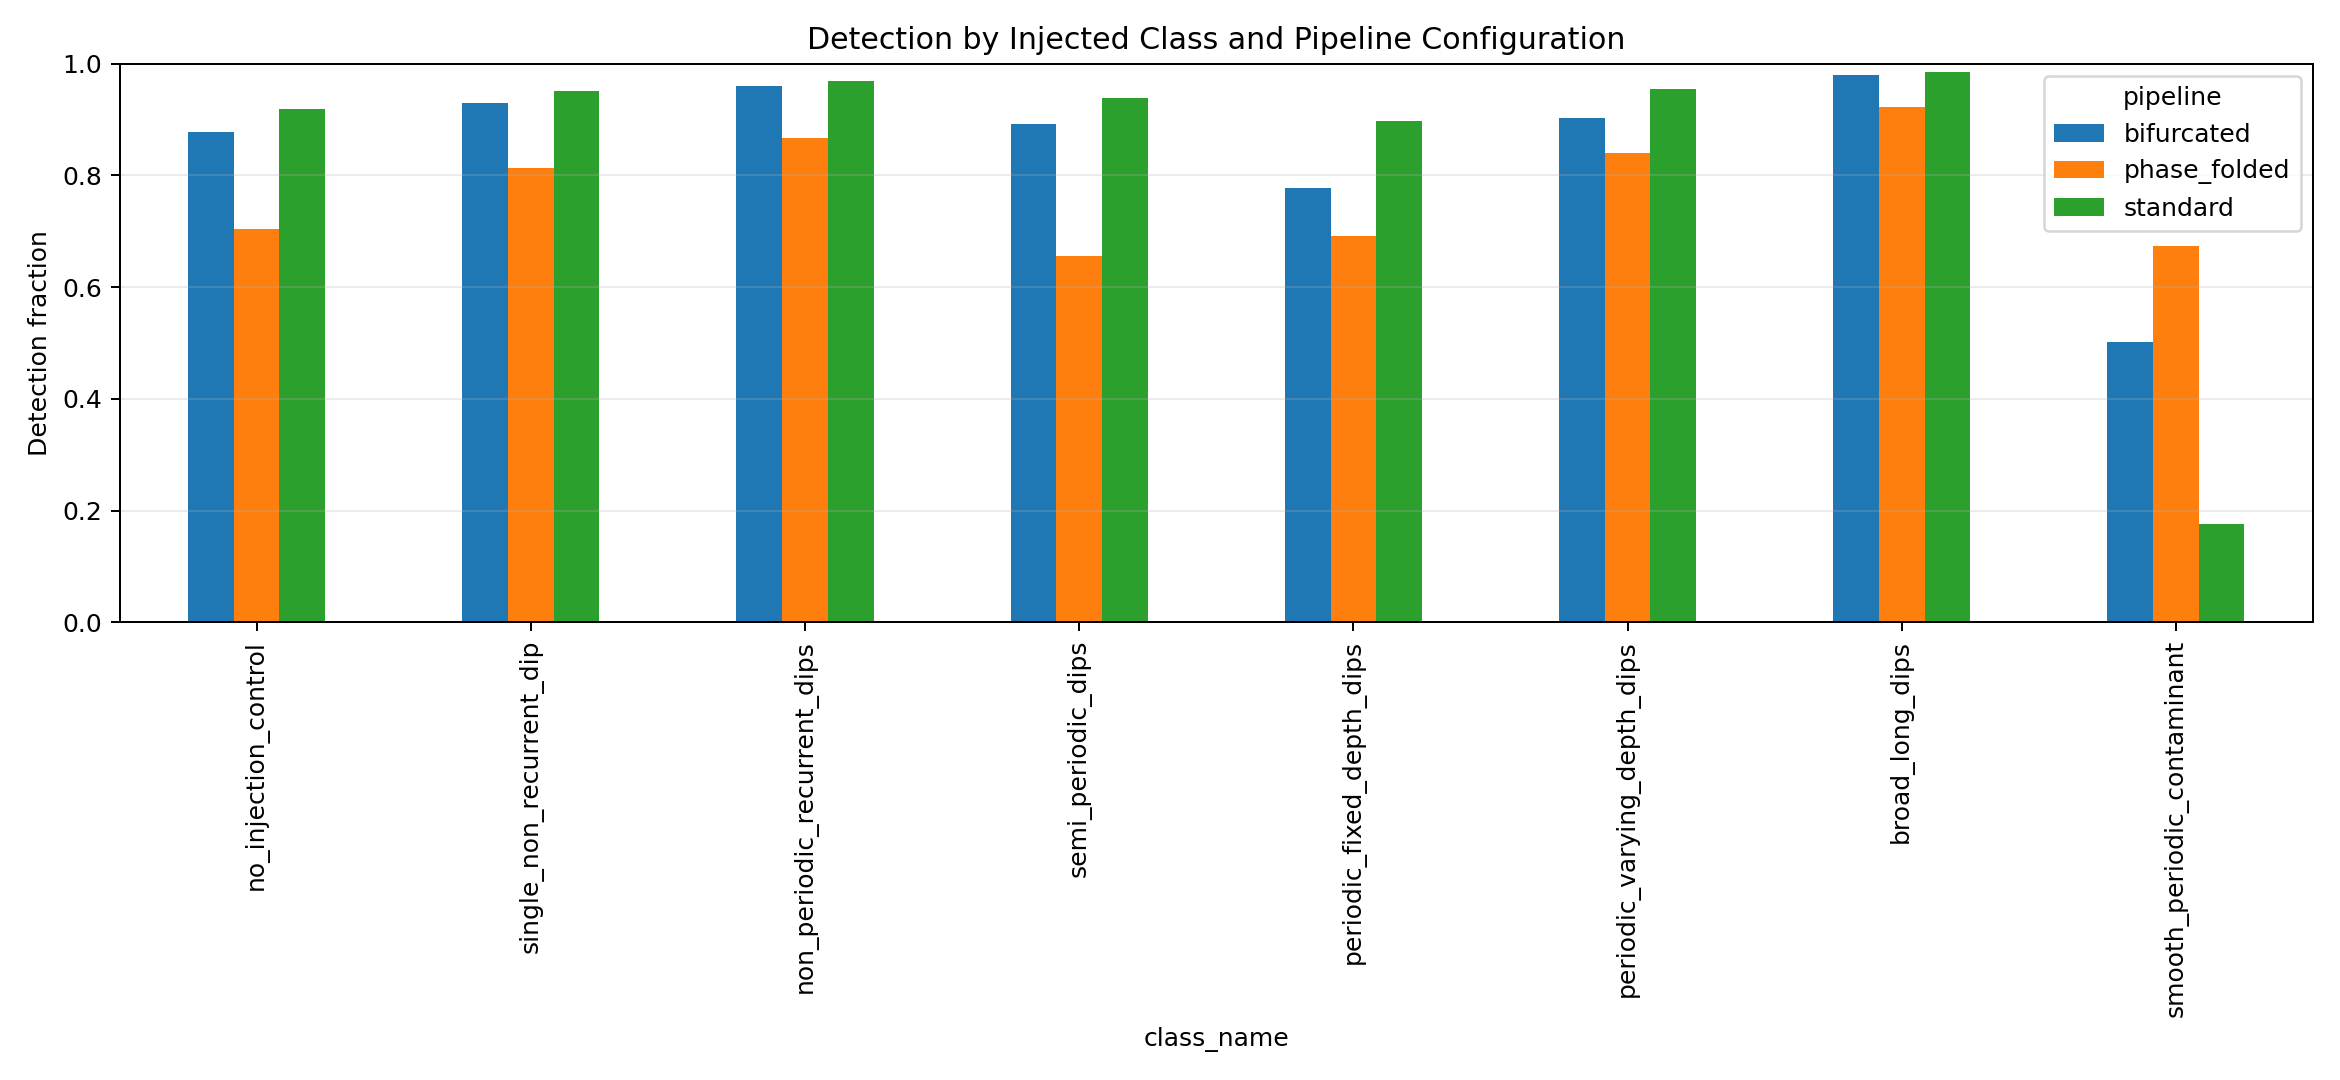

/home/calder/code/malca/output/diagnostics/periodicity_gate_injection_benchmark/20260513_162637/plots/gate_routing_confusion.png


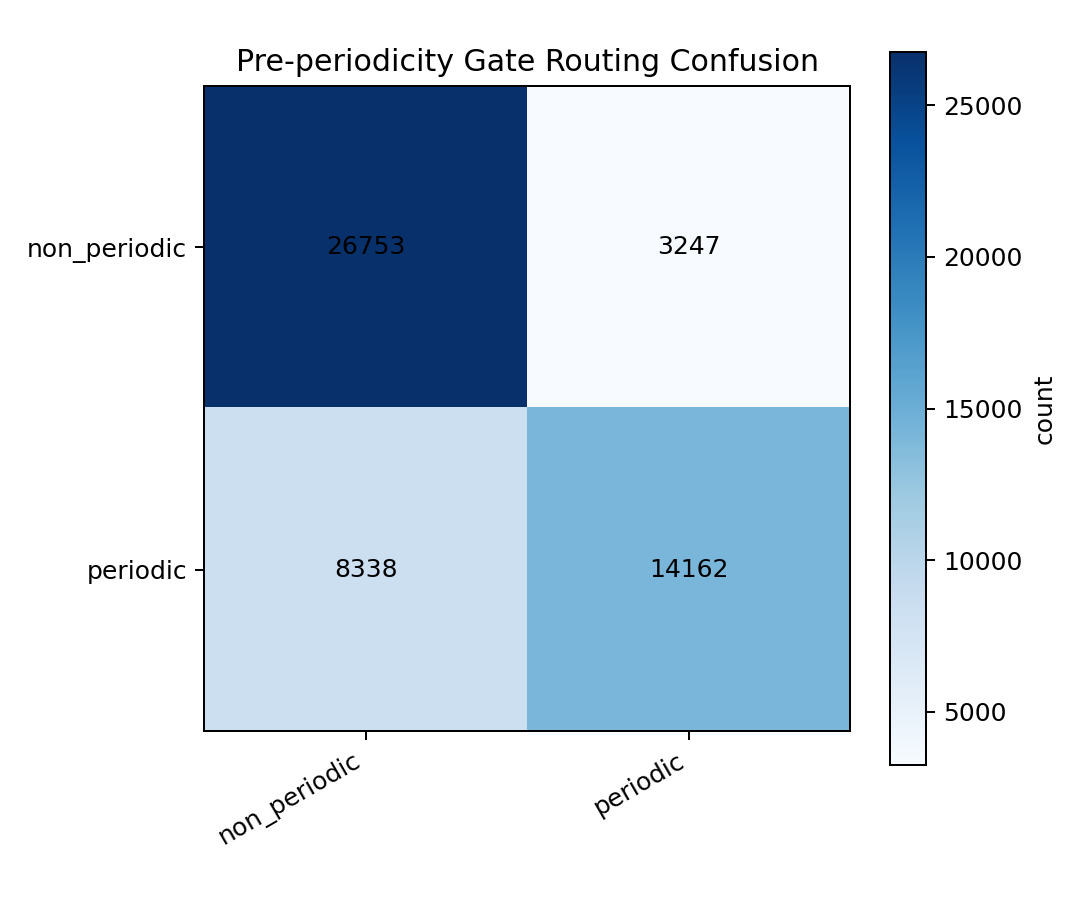

/home/calder/code/malca/output/diagnostics/periodicity_gate_injection_benchmark/20260513_162637/plots/recovery_vs_injection_parameters.png


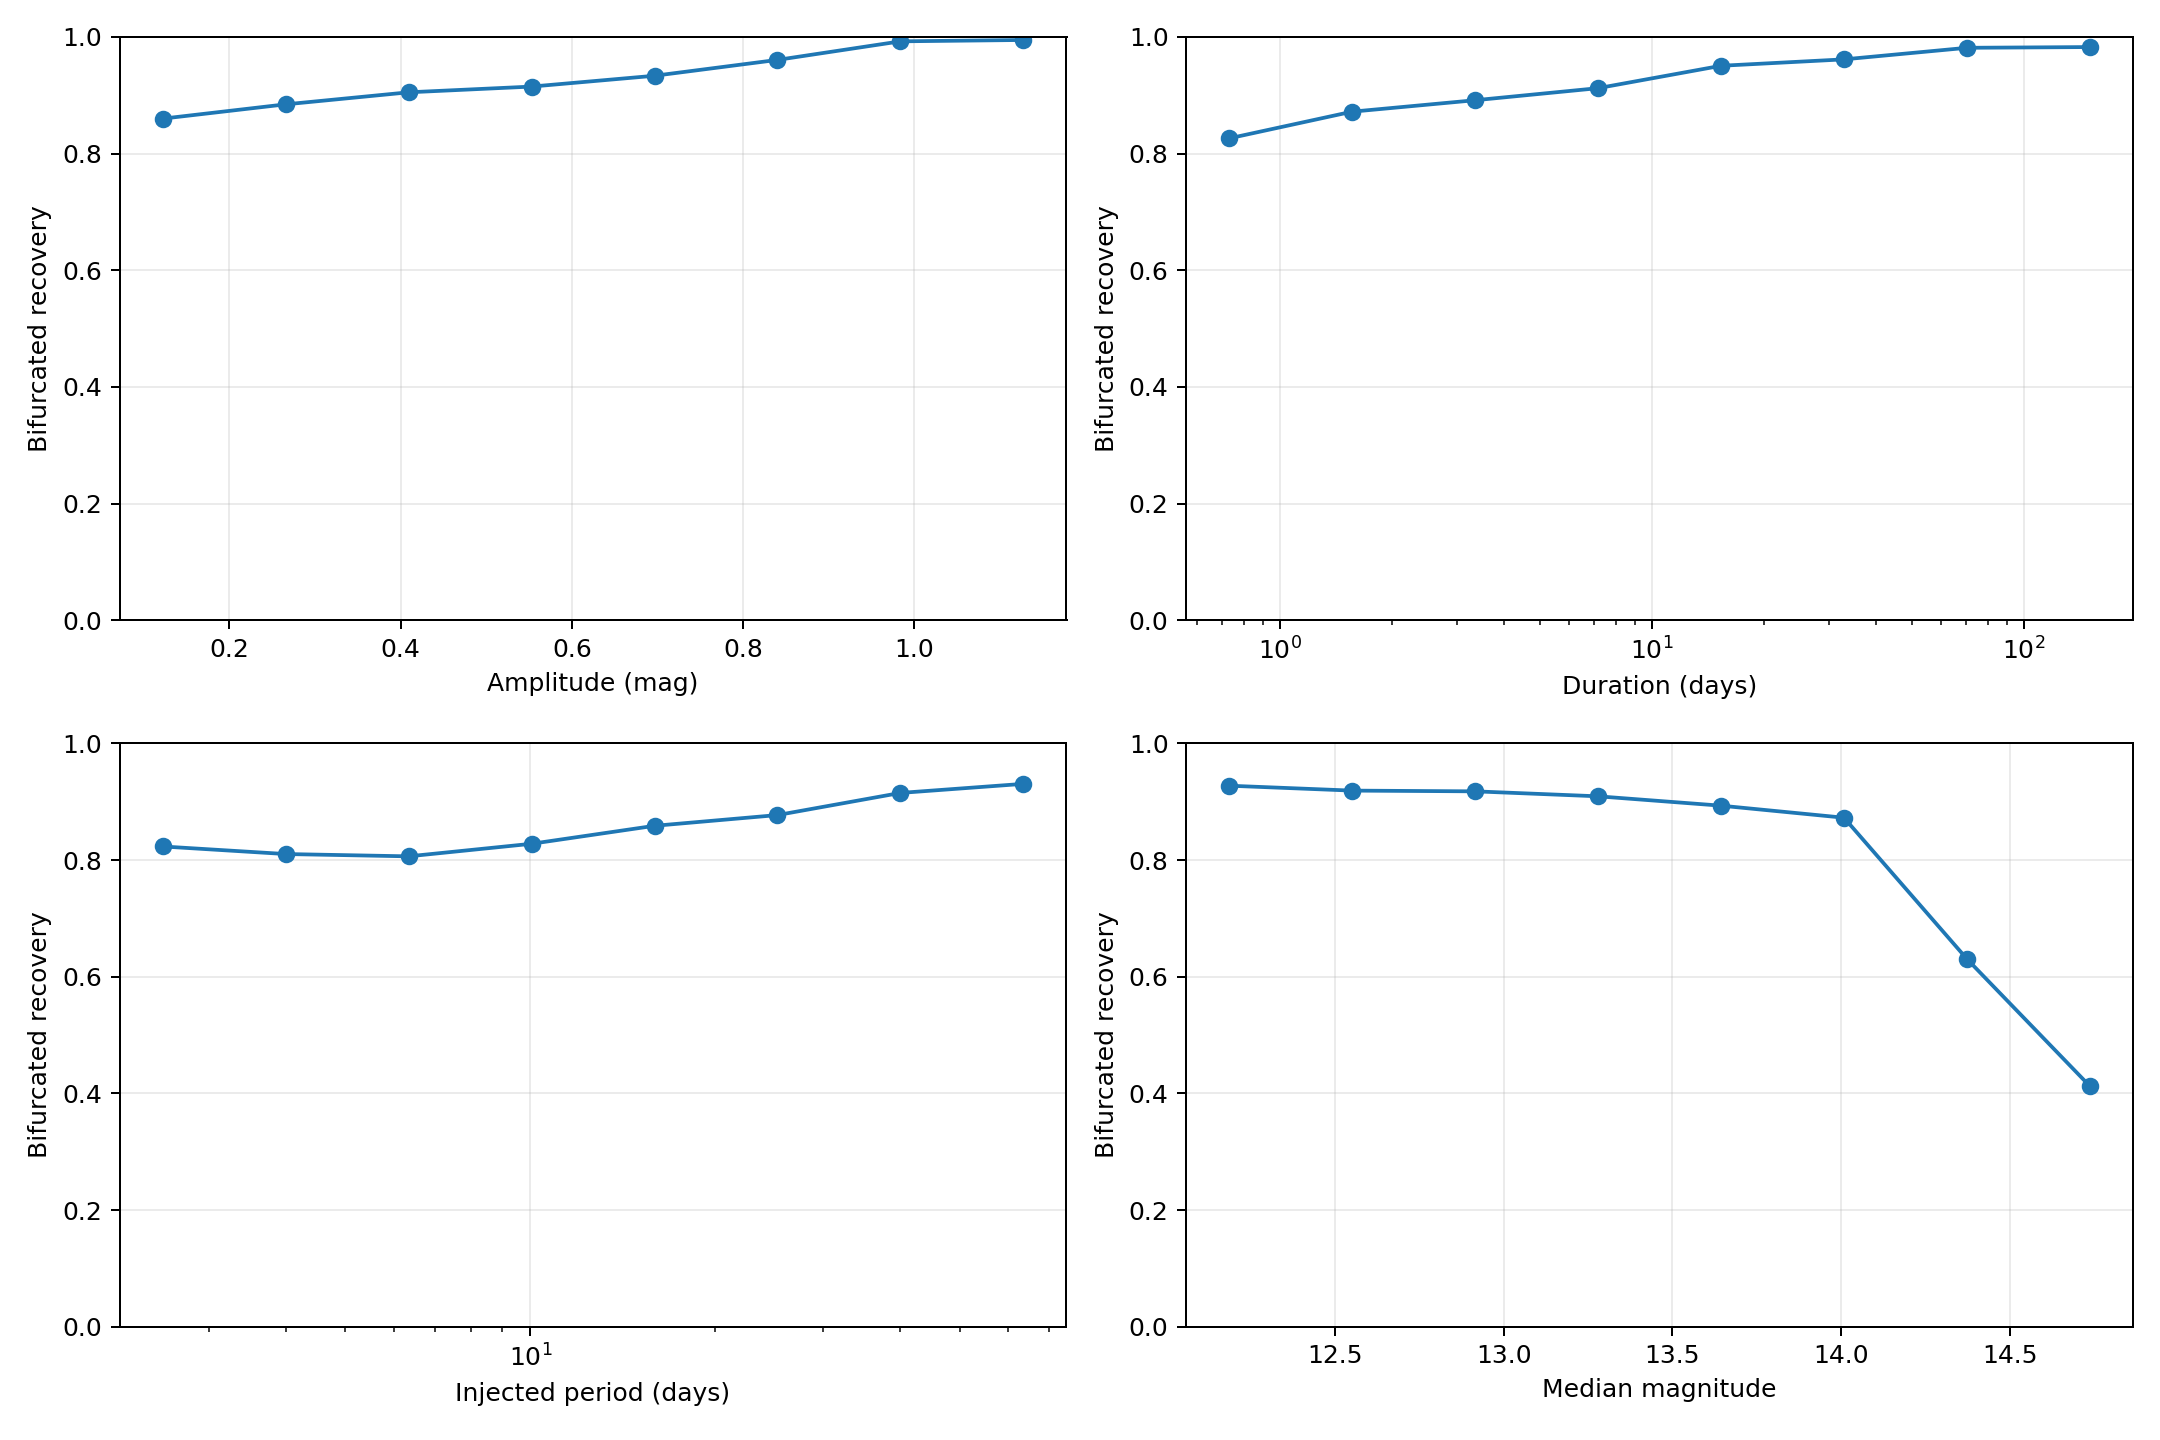

/home/calder/code/malca/output/diagnostics/periodicity_gate_injection_benchmark/20260513_162637/plots/threshold_heatmap_target_recovery.png


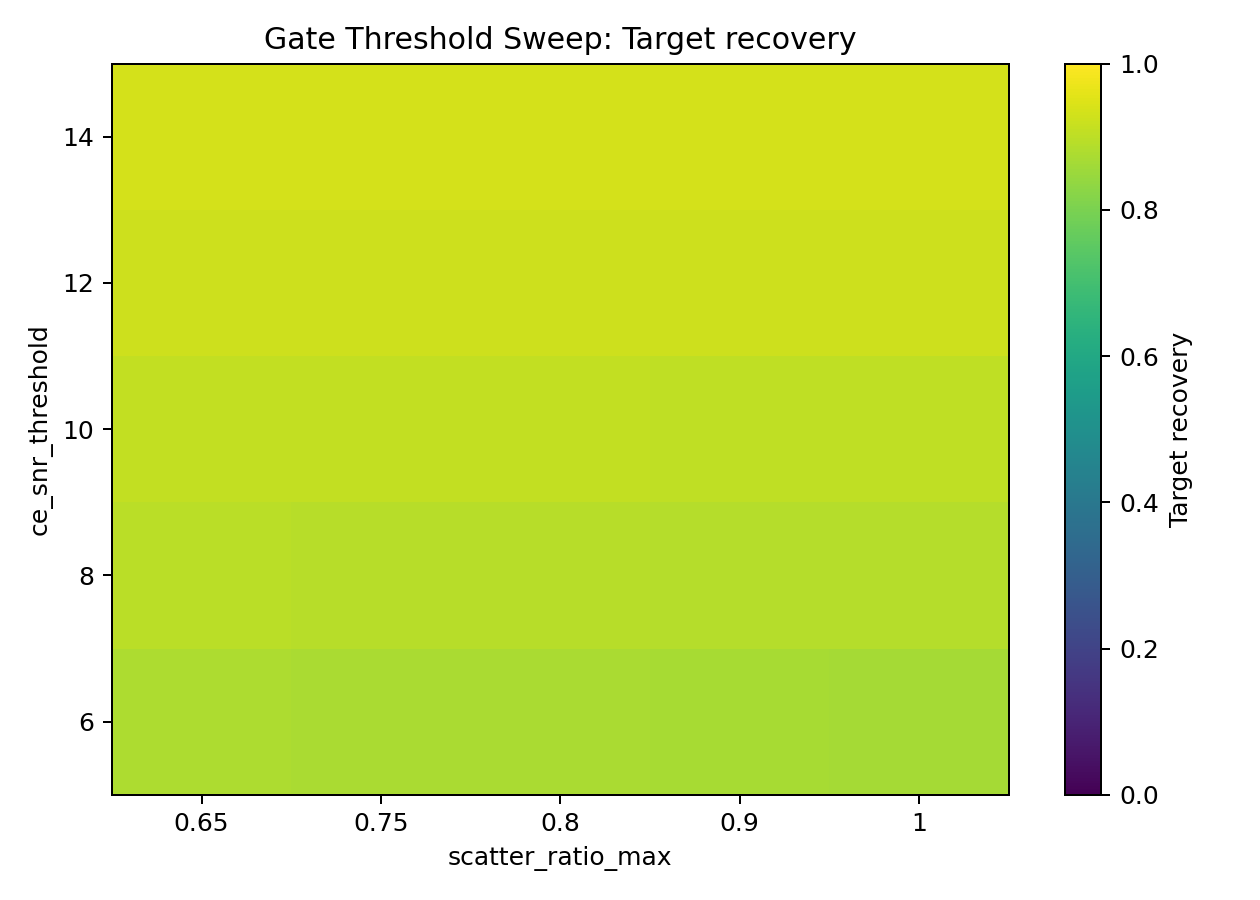

/home/calder/code/malca/output/diagnostics/periodicity_gate_injection_benchmark/20260513_162637/plots/threshold_heatmap_gate_false_periodic_route_rate.png


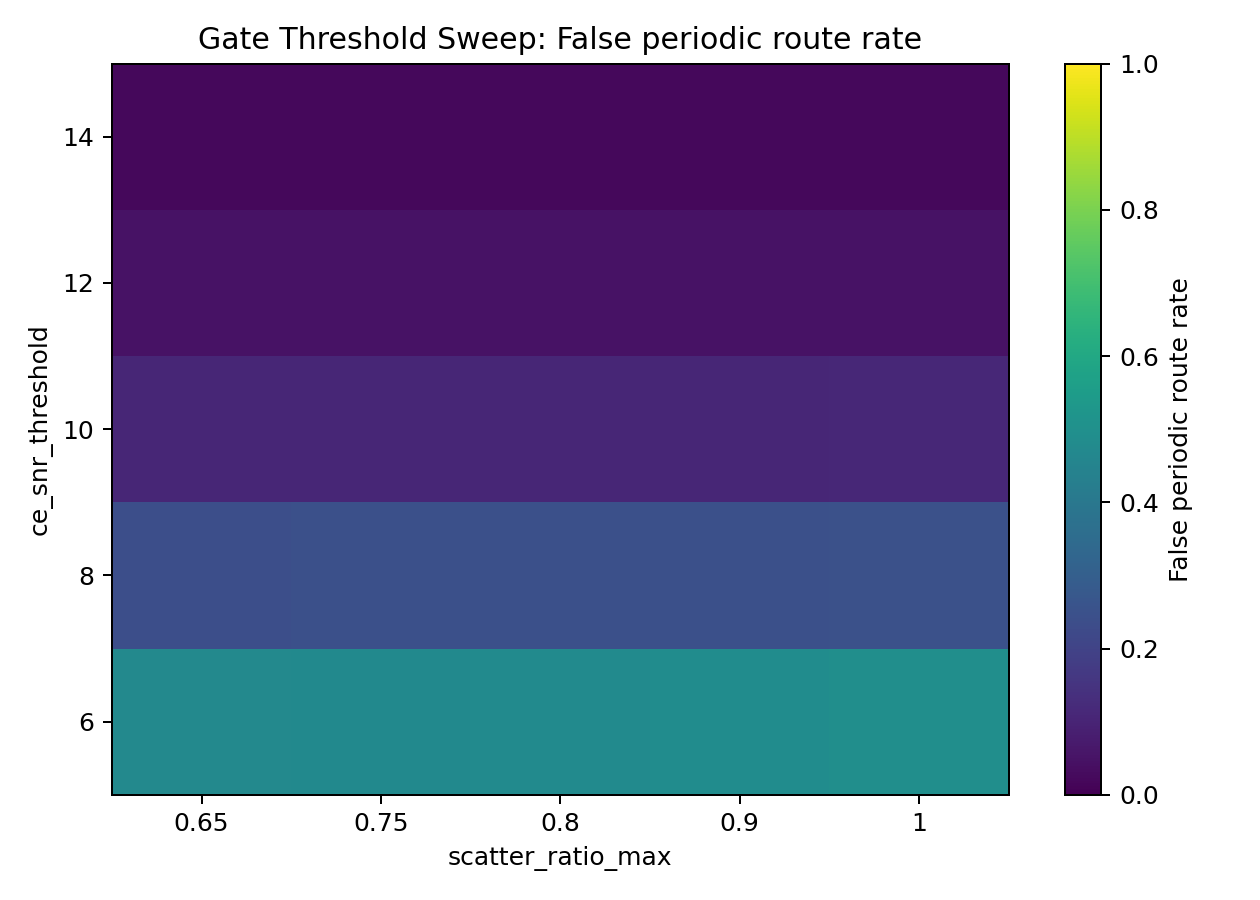

/home/calder/code/malca/output/diagnostics/periodicity_gate_injection_benchmark/20260513_162637/plots/threshold_heatmap_periodic_branch_load.png


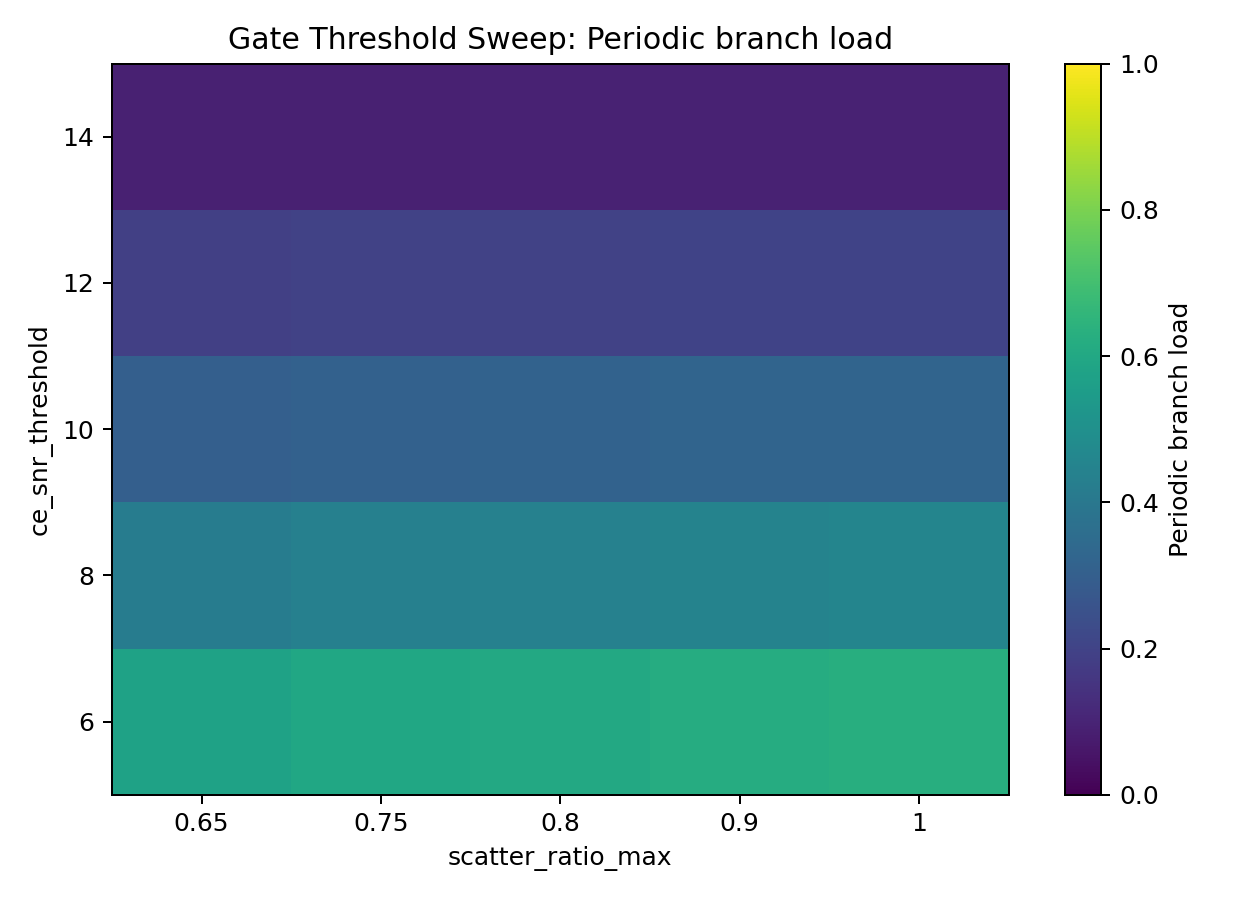

/home/calder/code/malca/output/diagnostics/periodicity_gate_injection_benchmark/20260513_162637/plots/gate_sweep_pareto.png


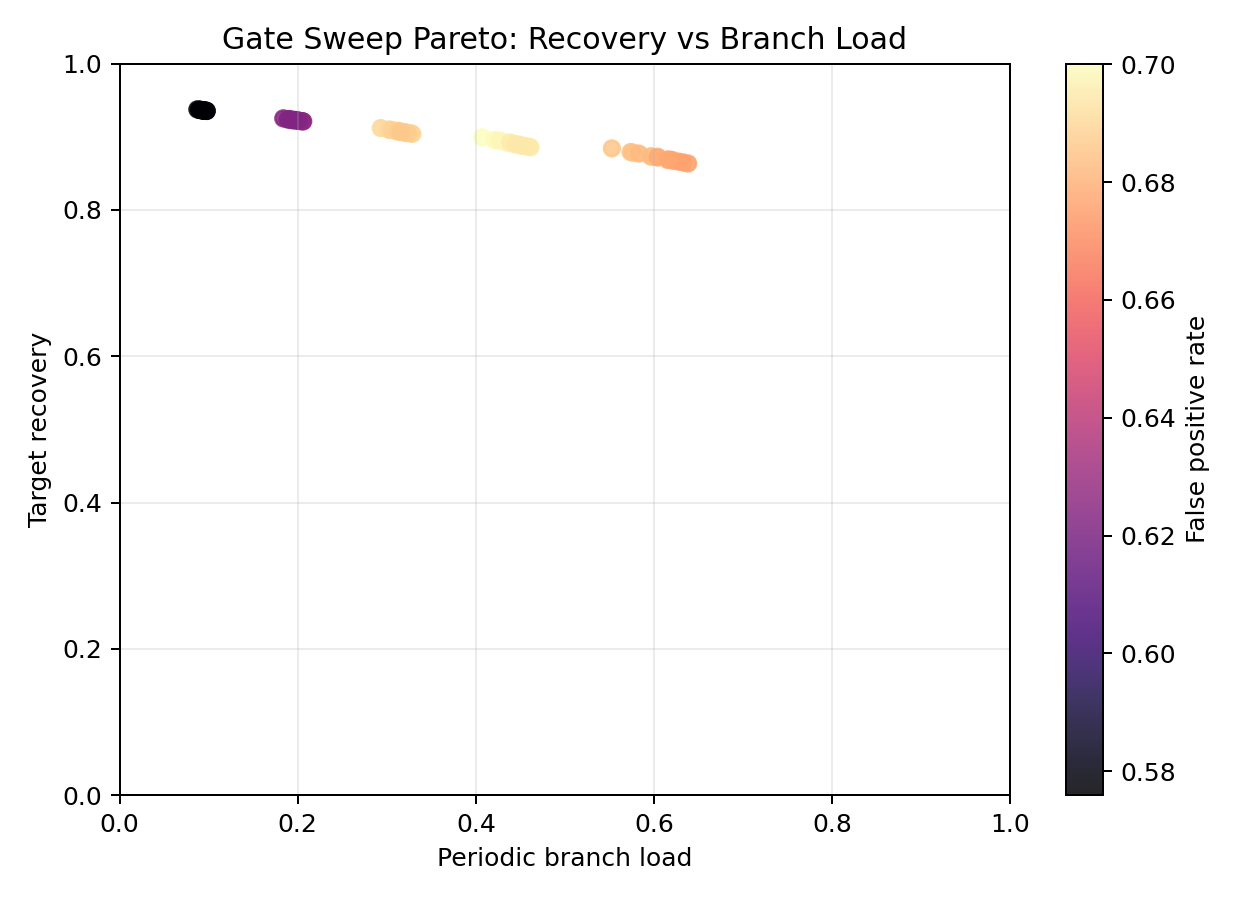

/home/calder/code/malca/output/diagnostics/periodicity_gate_injection_benchmark/20260513_162637/plots/representative_gate_examples.png


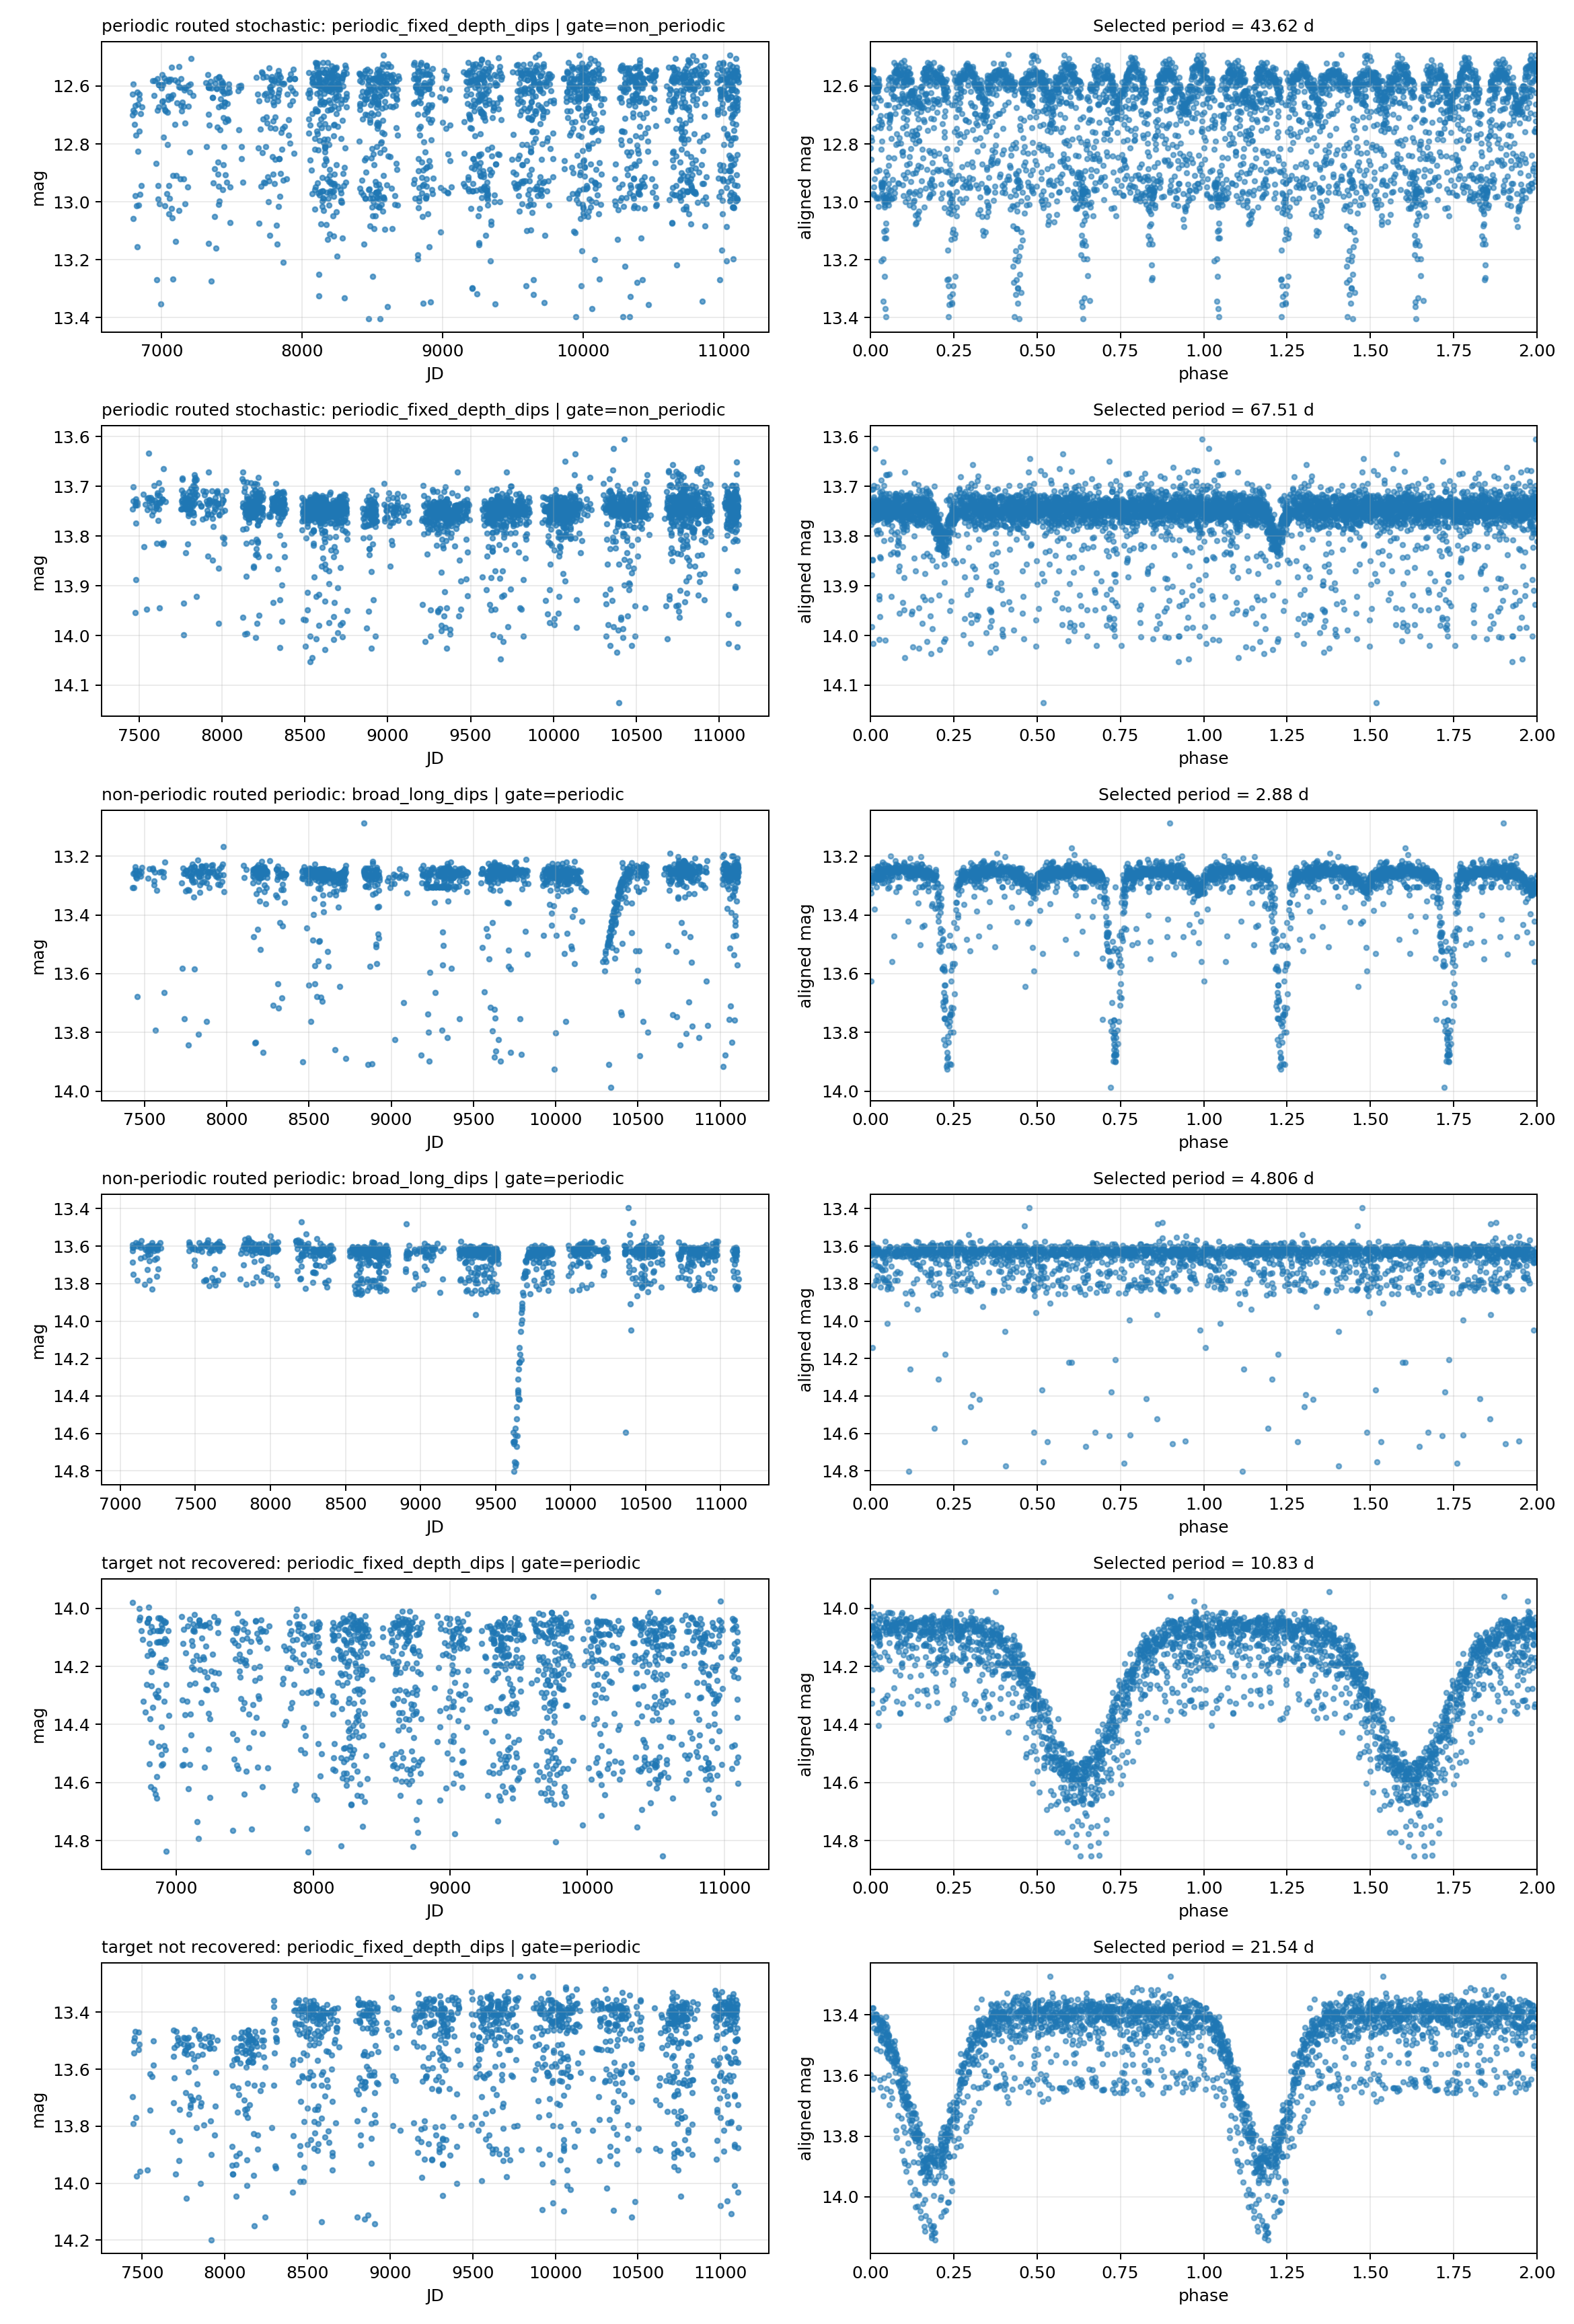

In [6]:
plot_paths = [
    run.run_dir / "plots/recovery_by_class_pipeline.png",
    run.run_dir / "plots/gate_routing_confusion.png",
    run.run_dir / "plots/recovery_vs_injection_parameters.png",
    run.run_dir / "plots/threshold_heatmap_target_recovery.png",
    run.run_dir / "plots/threshold_heatmap_gate_false_periodic_route_rate.png",
    run.run_dir / "plots/threshold_heatmap_periodic_branch_load.png",
    run.run_dir / "plots/gate_sweep_pareto.png",
    run.run_dir / "plots/representative_gate_examples.png",
    run.run_dir / "plots/standard_no_injection_false_positives.png",
]

for path in plot_paths:
    if path.exists():
        print(path)
        display(Image(filename=str(path)))
    else:
        print(f"Missing plot: {path}")